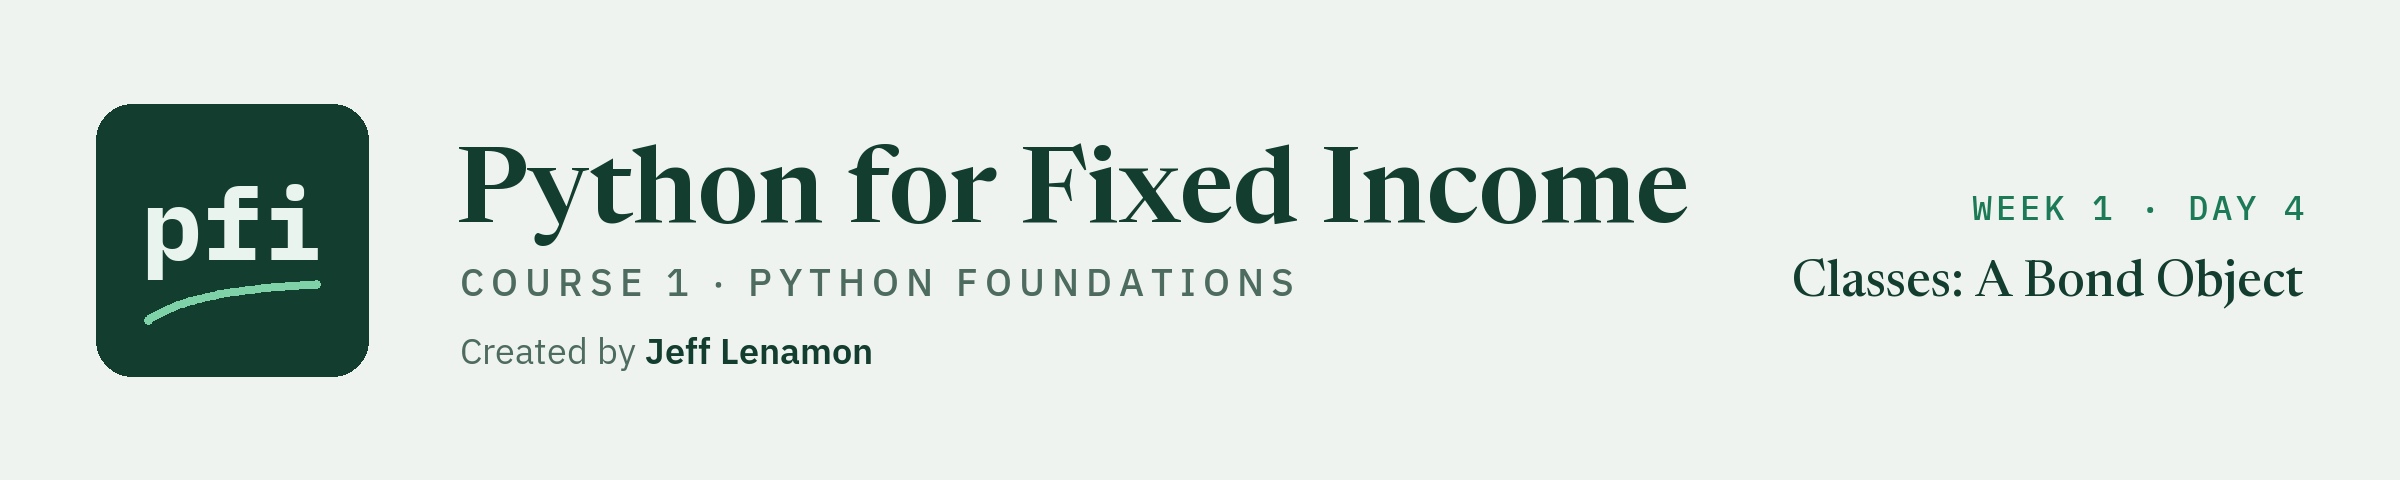

# Classes: A Bond Object

Week 1. Bundling a bond's data and its calculations into one object.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week1/day4/04_classes_a_bond_object.ipynb)

So far the credit desk has described a bond three ways: as loose variables, as matching positions in several lists, and as a dictionary. Each holds the bond's data. None of them holds the bond's calculations. The function for current yield lives somewhere else, and nothing ties it to the bond it belongs to.

A **class** fixes that. It lets us define our own kind of object, a `Bond`, that carries its data and knows how to do its own calculations. This way of writing code is called object oriented programming.

We use the same four bonds as before. The issuers are invented.

| Ticker | Coupon (%) | Maturity | Price | Face held |
| --- | --- | --- | --- | --- |
| QVNE | 5.25 | 2033 | 98.50 | 1,500,000 |
| DNMR | 6.125 | 2034 | 103.25 | 500,000 |
| PLWK | 4.75 | 2031 | 95.00 | 750,000 |
| HLVF | 7.50 | 2032 | 101.00 | 250,000 |

## 4.1 Objects Are Already Everywhere

Before writing a class, notice that we have been using them all along.

Q. What is the data type of the QVNE coupon and of its ticker?

In [1]:
coupon = 5.25
ticker = 'QVNE'

print(type(coupon))
print(type(ticker))

<class 'float'>
<class 'str'>


* Look closely at the output: `<class 'float'>` and `<class 'str'>`. Every data type in Python is a class.
* `float` is the class. The value 5.25 is one **object** of that class. The value 98.5 is another object of the same class. Same type, different values.

Q. Convert the ticker to lower case.

In [2]:
# lower() is a function that belongs to every string
print(ticker.lower())

qvne


* A function that belongs to a class is called a **method**. We call it with a dot after the object. Every string object can do this, because the `str` class defines it.

So a class has two parts: the data each object holds, and the methods each object can run. Python gives us classes for numbers and text. Now we write one for a bond.

## 4.2 A First Class

Q. Define a class named **Bond** that can store a ticker, a coupon, and a price, and can calculate its own current yield.

In [3]:
# by convention, a class name starts with a capital letter
class Bond:
    # a function defined inside a class is a method
    # the first argument of every method is self, which stands for the object itself
    def set_terms(self, ticker, coupon, price):
        # store each value on the object. A variable stored on an object is called an attribute.
        self.ticker = ticker
        self.coupon = coupon
        self.price = price

    # this method uses the object's own attributes and returns a value
    def current_yield(self):
        return self.coupon / self.price * 100

* Nothing is printed. Like a function, a class is only a definition until we use it. Think of it as a blank form: it says what a bond record contains, but it is not yet any particular bond.

Q. Create a Bond object for QVNE.

In [4]:
# calling the class creates one object of that class
qvne = Bond()
# fill in its terms. We do not pass self. Python supplies it.
qvne.set_terms('QVNE', 5.25, 98.5)

In [5]:
# check the data type
type(qvne)

__main__.Bond

* `qvne` is an object of the class `Bond`, in the same way that 5.25 is an object of the class `float`. We have made our own data type.

Q. Print the coupon of the object, and its current yield.

In [6]:
# an attribute is reached with a dot and has no brackets
print(qvne.coupon)
# a method is called with a dot and round brackets
print(qvne.current_yield())

5.25
5.32994923857868


* The object holds its data and does its own calculation. We never passed the coupon or the price to `current_yield()`. The method found them on the object through `self`.

Inside the class, `self` means 'this object'. What happens if we use `self` outside the class?

In [7]:
print(self.coupon)

NameError: name 'self' is not defined

* A `NameError`. `self` is the first argument of each method, so it exists only while a method is running. Outside the class, we use the object's own name: `qvne.coupon`.

Q. Create a second Bond object for DNMR and print its current yield.

In [8]:
dnmr = Bond()
dnmr.set_terms('DNMR', 6.125, 103.25)
print(dnmr.current_yield())

5.932203389830509


In [9]:
# the first object is unchanged
print(qvne.current_yield())

5.32994923857868


* The same method gives a different answer for each object, because each object carries its own attributes. One class, many objects.

## 4.3 The Trouble With Loose Attributes

Python lets us attach a new attribute to an object from outside the class.

Q. Record the sector of QVNE on the object.

In [10]:
# add an attribute from outside the class
qvne.sector = 'Energy'
print(qvne.sector)

Energy


It works. Now let's ask DNMR for its sector.

In [11]:
print(dnmr.sector)

AttributeError: 'Bond' object has no attribute 'sector'

* An `AttributeError`: this Bond object has no attribute 'sector'. We added the sector to one object only.
* This is why adding attributes from outside is a bad habit. Every object of a class should have the same set of attributes, even though the values differ. Otherwise code that works on one bond fails on the next.

There is a second weakness. Nothing forces us to call `set_terms()`.

Q. Create a Bond object for PLWK and print its coupon.

In [12]:
plwk = Bond()
print(plwk.coupon)

AttributeError: 'Bond' object has no attribute 'coupon'

* Another `AttributeError`. The object exists, but it is an empty form. We created it and forgot to fill it in.
* We want every Bond to have its terms from the moment it is created.

## 4.4 The Initializer

A method named `__init__` (two underscores on each side) is special. Python runs it automatically whenever an object is created. It is called the **initializer**, and it is where an object's attributes are set.

Q. Rewrite the Bond class so that every bond gets its ticker, coupon, maturity, price, and face held when it is created. Give it methods for current yield, annual coupon income, market value, and a printed description.

In [13]:
class Bond:
    # __init__ runs automatically when a Bond is created
    def __init__(self, ticker, coupon, maturity, price, face):
        self.ticker = ticker
        self.coupon = coupon
        self.maturity = maturity
        self.price = price
        self.face = face

    def current_yield(self):
        # coupon divided by price, in percent
        return self.coupon / self.price * 100

    def annual_income(self):
        # the coupon is in percent, so divide by 100
        return self.face * self.coupon / 100

    def market_value(self):
        # face at today's price. The price is per 100 face, so divide by 100
        return self.face * self.price / 100

    def describe(self):
        print(self.ticker, ' ', self.coupon, '% of ', self.maturity, sep='')
        print('  Face held:', self.face, 'at a price of', self.price)
        # a method can call another method of the same object through self
        print('  Current yield:', round(self.current_yield(), 2), 'percent')

Q. Create a Bond object for each of the four bonds.

In [14]:
# the values in the brackets are passed to __init__
qvne = Bond('QVNE', 5.25, 2033, 98.5, 1500000)
dnmr = Bond('DNMR', 6.125, 2034, 103.25, 500000)
plwk = Bond('PLWK', 4.75, 2031, 95.0, 750000)
hlvf = Bond('HLVF', 7.5, 2032, 101.0, 250000)

* One line per bond. Creating the object and filling it in are now a single step.

Q. Print a description of QVNE and of HLVF.

In [15]:
qvne.describe()
print('')
hlvf.describe()

QVNE 5.25% of 2033
  Face held: 1500000 at a price of 98.5
  Current yield: 5.33 percent

HLVF 7.5% of 2032
  Face held: 250000 at a price of 101.0
  Current yield: 7.43 percent


What happens now if we leave something out?

In [16]:
# the face held is missing
osmc = Bond('OSMC', 5.0, 2035, 100.0)

TypeError: Bond.__init__() missing 1 required positional argument: 'face'

* A `TypeError` that names the missing argument: `face`. The initializer will not create a half-filled bond. The weakness from section 4.3 is gone.

## 4.5 Working With an Object

Q. What is the market value of the QVNE position, and how much coupon does it pay each year?

In [17]:
print('Market value:', qvne.market_value())
print('Annual coupon income:', qvne.annual_income())

Market value: 1477500.0
Annual coupon income: 78750.0


Q. QVNE is marked at 99.25. Update the price on the object and print the market value again.

In [18]:
# an attribute can be changed from outside the class
qvne.price = 99.25
print('Market value:', qvne.market_value())

Market value: 1488750.0


* The market value moved from 1,477,500 to 1,488,750. The method worked it out again from the new price. Because `market_value()` calculates from the attributes every time it is called, it can never be out of date.

That is a deliberate design choice. Here is what happens when a class does it the other way and stores the result.

In [19]:
class BondWithStoredValue:
    def __init__(self, ticker, price, face):
        self.ticker = ticker
        self.price = price
        self.face = face
        # the market value is calculated once, here, and stored as an attribute
        self.stored_value = self.face * self.price / 100

In [20]:
stale = BondWithStoredValue('QVNE', 98.5, 1500000)
print('Market value before the price change:', stale.stored_value)

# mark the price to 99.25
stale.price = 99.25
print('Market value after the price change:', stale.stored_value)

Market value before the price change: 1477500.0
Market value after the price change: 1477500.0


* The price changed and the stored market value did not. There is no error. The object still says 1,477,500 when the position is now worth 1,488,750.
* The rule: store the facts as attributes, and calculate anything that depends on them in a method.
* Book cost is a different thing. It is what was paid at the trade, so it is a fact, and it does not move when the bond is re-marked.

Setting `qvne.price` directly works, but a method can do the same job and say what it is for.

Q. Add a method to the Bond class that marks the bond to a new price.

In [21]:
class Bond:
    def __init__(self, ticker, coupon, maturity, price, face):
        self.ticker = ticker
        self.coupon = coupon
        self.maturity = maturity
        self.price = price
        self.face = face

    def current_yield(self):
        return self.coupon / self.price * 100

    def annual_income(self):
        return self.face * self.coupon / 100

    def market_value(self):
        return self.face * self.price / 100

    def mark(self, new_price):
        # a method can change the object's own attributes
        self.price = new_price

    def describe(self):
        print(self.ticker, ' ', self.coupon, '% of ', self.maturity, sep='')
        print('  Face held:', self.face, 'at a price of', self.price)
        print('  Current yield:', round(self.current_yield(), 2), 'percent')

* Redefining a class does not update objects that were made from the old version. The four bonds have to be created again.

In [22]:
qvne = Bond('QVNE', 5.25, 2033, 98.5, 1500000)
dnmr = Bond('DNMR', 6.125, 2034, 103.25, 500000)
plwk = Bond('PLWK', 4.75, 2031, 95.0, 750000)
hlvf = Bond('HLVF', 7.5, 2032, 101.0, 250000)

In [23]:
print('Current yield before:', round(qvne.current_yield(), 2))
# mark QVNE to 99.25
qvne.mark(99.25)
print('Current yield after:', round(qvne.current_yield(), 2))

Current yield before: 5.33
Current yield after: 5.29


In [24]:
# put the price back so the object matches the table again
qvne.mark(98.5)

## 4.6 A Portfolio of Objects

Objects can be stored in a list like any other value. This is where a class pays for itself.

Q. Put the four bonds in a list and print each one's ticker and current yield.

In [25]:
# a list of Bond objects
portfolio = [qvne, dnmr, plwk, hlvf]

for bond in portfolio:
    print(bond.ticker, 'has a current yield of', round(bond.current_yield(), 2), 'percent')

QVNE has a current yield of 5.33 percent
DNMR has a current yield of 5.93 percent
PLWK has a current yield of 5.0 percent
HLVF has a current yield of 7.43 percent


* Compare this with the loops in the first notebook, which had to step through three or four lists at once with `zip()`. Here each bond carries everything it needs.

Q. What is the market value of the whole portfolio, and what is its annual coupon income?

In [26]:
# start two running totals at zero
total_value = 0
total_income = 0
for bond in portfolio:
    total_value = total_value + bond.market_value()
    total_income = total_income + bond.annual_income()

print('Total market value:', total_value)
print('Total annual coupon income:', total_income)

Total market value: 2958750.0
Total annual coupon income: 163750.0


* 2,958,750 and 163,750. Both match the totals from the first notebook, reached with far less bookkeeping. The prices are the same as in that notebook, so the market value here equals the cost worked out there.

Q. Which bonds trade at a discount?

In [27]:
# a list comprehension over objects
discount_tickers = [bond.ticker for bond in portfolio if bond.price < 100]
print(discount_tickers)

['QVNE', 'PLWK']


Q. Which bond has the highest coupon?

In [28]:
# start with the first bond, then replace it whenever a higher coupon turns up
highest = portfolio[0]
for bond in portfolio:
    if bond.coupon > highest.coupon:
        highest = bond

print(highest.ticker, 'has the highest coupon at', highest.coupon)

HLVF has the highest coupon at 7.5


**Excel side by side.** A class is like the header row of a holdings sheet, together with its formula columns. The plain columns (ticker, coupon, price, face) are the attributes. The formula columns (market value, current yield) are the methods. Each row is one object. Filling a formula down the column is what calling the method on every bond in a loop does.

## 4.7 Printing an Object

Q. What happens when we print a Bond object directly?

In [29]:
print(qvne)

* Python shows the class name and the object's address in the computer's memory. Your address will differ. It is accurate, and no use to a person.

A method named `__str__` tells Python what text to show when an object is printed. It must return a string.

Q. Add a `__str__` method so that printing a bond shows its ticker, coupon, and maturity.

In [30]:
class Bond:
    def __init__(self, ticker, coupon, maturity, price, face):
        self.ticker = ticker
        self.coupon = coupon
        self.maturity = maturity
        self.price = price
        self.face = face

    def __str__(self):
        # return the text to show when the object is printed
        return self.ticker + ' ' + str(self.coupon) + '% of ' + str(self.maturity)

    def current_yield(self):
        return self.coupon / self.price * 100

    def annual_income(self):
        return self.face * self.coupon / 100

    def market_value(self):
        return self.face * self.price / 100

    def mark(self, new_price):
        self.price = new_price

In [31]:
qvne = Bond('QVNE', 5.25, 2033, 98.5, 1500000)
print(qvne)

QVNE 5.25% of 2033


* Now the object describes itself. Methods with two underscores on each side, like `__init__` and `__str__`, are ones Python calls for us at set moments: when an object is created, and when it is printed.
* `__str__` is used when the object itself is printed. A list of bonds, or a bond shown as the last line of a cell without `print()`, still shows the address form. That form is set by a second method, `__repr__`, which we do not need here.

## Exercises

A second desk holds three positions. The issuers are invented.

| Ticker | Face held | Price |
| --- | --- | --- |
| TRNW | 2,000,000 | 96.25 |
| OSMC | 1,250,000 | 100.00 |
| CLDB | 500,000 | 104.50 |

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It defines `check`, which marks your answers.

In [32]:
def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
    elif answer == expected:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)

### Exercise 1

Q. Complete the class **Position** below. The initializer should store the ticker, face, and price. The method `market_value()` should return face times price divided by 100. Then the code creates the TRNW position and stores its market value in **ex1_market_value**.

In [33]:
class Position:
    def __init__(self, ticker, face, price):
        ...

    def market_value(self):
        return ...


trnw = Position('TRNW', 2000000, 96.25)
ex1_market_value = trnw.market_value()

In [34]:
check('Exercise 1', ex1_market_value, 1925000.0)

Exercise 1: not attempted yet


### Exercise 2

Q. Write the class again and add a method `is_premium()` that returns True when the price is above 100 and False otherwise. Then create all three positions. The code stores whether CLDB is at a premium in **ex2_cldb_premium** and whether OSMC is in **ex2_osmc_premium**.

In [35]:
class Position:
    def __init__(self, ticker, face, price):
        ...

    def market_value(self):
        return ...

    def is_premium(self):
        return ...


trnw = Position('TRNW', 2000000, 96.25)
osmc = Position('OSMC', 1250000, 100.0)
cldb = Position('CLDB', 500000, 104.5)

ex2_cldb_premium = cldb.is_premium()
ex2_osmc_premium = osmc.is_premium()

In [36]:
check('Exercise 2 CLDB', ex2_cldb_premium, True)
check('Exercise 2 OSMC', ex2_osmc_premium, False)

Exercise 2 CLDB: not attempted yet
Exercise 2 OSMC: not attempted yet


### Exercise 3

Q. Put the three positions in a list and use a loop to find the total market value. Store it in **ex3_total_value**.

In [37]:
ex3_total_value = ...

In [38]:
check('Exercise 3', ex3_total_value, 3697500.0)

Exercise 3: not attempted yet


### Exercise 4

Q. The desk sells 500,000 face of TRNW, leaving 1,500,000. Update the face on the TRNW object, then store its new market value in **ex4_market_value**.

In [39]:
ex4_market_value = ...

In [40]:
check('Exercise 4', ex4_market_value, 1443750.0)

Exercise 4: not attempted yet


### Exercise 5

Q. Write the class once more and add a `__str__` method, so that printing a position shows its ticker, its face with thousands separators, and its price to 2 decimals, in this form: `CLDB 500,000 at 104.50`. Build the text with an f-string. Then store `str(cldb)` in **ex5_text**. `str()` gives the same text that `print()` shows.

In [41]:
class Position:
    def __init__(self, ticker, face, price):
        ...

    def market_value(self):
        return ...

    # add the __str__ method here


cldb = Position('CLDB', 500000, 104.5)
ex5_text = ...

In [42]:
check('Exercise 5', ex5_text, 'CLDB 500,000 at 104.50')

Exercise 5: not attempted yet


### Exercise 6: AI check

You ask an AI assistant for a position class with a method that marks the position to a new price. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

The code creates a position of 2,000,000 face at a price of 96.25, marks it to 97.00, and prints the market value.

Q. Before you run it, work out what the market value should be after the mark. Then run the code. Does it agree with you?

In [43]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
class MarkedPosition:
    def __init__(self, ticker, face, price):
        self.ticker = ticker
        self.face = face
        self.price = price

    def market_value(self):
        return self.face * self.price / 100

    def mark(self, new_price):
        price = new_price


marked = MarkedPosition('TRNW', 2000000, 96.25)
marked.mark(97.0)
ex6_value_after_mark = marked.market_value()
print(f'Market value after the mark: {ex6_value_after_mark:,.2f}')

Market value after the mark: 1,925,000.00


Q. Find the bug and fix the code in the cell above, so that **ex6_value_after_mark** holds the right answer.

In [44]:
check('Exercise 6', ex6_value_after_mark, 1940000.0)

Exercise 6: not yet. You have 1925000.0
